# Task 3 — BERT: MLM pretraining + Classification fine-tuning (with W&B)

**Project:** NALAPRO &nbsp;|&nbsp; **Dataset:** 20 Newsgroups &nbsp;|&nbsp; **Backbone:** `bert-base-uncased`

Two phases:
1. **Phase 1 — Masked Language Modeling (MLM).** Continue pretraining BERT on the 20-newsgroups corpus with the masked-token objective. *No labels are used in this phase.*
2. **Phase 2 — Classification.** Fine-tune the MLM-adapted encoder on the 20-class classification task.

Comparison against Task 2 (vanilla BERT classification) isolates the value of the MLM adaptation step.

---

## Tools used
- **Hugging Face `transformers`** — BERT, tokenizer, `Trainer`, `DataCollatorForLanguageModeling`.
- **`datasets`** — in-memory tokenization.
- **`scikit-learn`** — `fetch_20newsgroups` and evaluation metrics.
- **Weights & Biases** — experiment tracking (training curves, hyperparameters, system metrics, confusion matrix).
- **PyTorch** — backend.
- **AI assistance** — Claude (Anthropic) was used to help structure the code; all logic was reviewed and is explainable.

**W&B project link:** paste your run URL here after the first training, e.g. `https://wandb.ai/<your-entity>/nalapro-task3`.

## 1. Install dependencies (Colab only)

Skip this cell if you've already installed everything locally.

In [1]:
# Pin transformers<5 to avoid v5 API surprises (overwrite_output_dir, tokenizer→processing_class rename, etc.)
%pip -q install "transformers>=4.40,<5" "datasets>=2.18" "accelerate>=0.27" "scikit-learn>=1.3" "wandb>=0.16"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00


## 2. Setup

In [2]:
import os, sys, json, logging, random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")
log = logging.getLogger("task3")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths — resolved so that running from task3/ or from the project root both work
HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "task3" else HERE
OUT_DIR      = PROJECT_ROOT / "outputs"
MLM_CKPT_DIR = OUT_DIR / "task3_mlm"
CLF_CKPT_DIR = OUT_DIR / "task3_clf_after_mlm"
FIG_DIR      = OUT_DIR / "figures" / "task3"
for d in (OUT_DIR, MLM_CKPT_DIR, CLF_CKPT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Outputs      :", OUT_DIR)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device       :", torch.cuda.get_device_name(0))


Project root : /content
Outputs      : /content/outputs
PyTorch      : 2.10.0+cu128
CUDA         : True
Device       : Tesla T4


## 3. Weights & Biases setup

You need a W&B account (free) and your API key from https://wandb.ai/authorize.

Three ways to authenticate, in order of recommendation:

1. **Colab Secrets (best for Colab)** — Left sidebar → key icon → add a secret named `WANDB_API_KEY`, paste the key, toggle "Notebook access" on. The cell below reads it automatically.
2. **Interactive prompt** — Run the cell with no env var set; W&B will prompt you to paste the API key once per session.
3. **Skip W&B** — Set `os.environ["WANDB_DISABLED"] = "true"` before running this cell. Training still works; you just lose the dashboard.

Setting `WANDB_PROJECT` here keeps all runs from this notebook grouped together.

In [3]:
import wandb

WANDB_PROJECT = "nalapro-task3"
os.environ["WANDB_PROJECT"] = WANDB_PROJECT

# Try Colab Secrets first; fall back to interactive login
try:
    from google.colab import userdata
    os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
    print("Loaded WANDB_API_KEY from Colab Secrets.")
except Exception:
    pass

# This is a no-op if WANDB_API_KEY is already set or ~/.netrc has credentials
wandb.login()
print("Logged in. Project:", WANDB_PROJECT)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: likhita-kolli (likhita-kolli-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged in. Project: nalapro-task3


## 4. Hyperparameters

One place for every knob. Keep the classifier section identical to Task 2 so the comparison is honest.

In [4]:
BASE_MODEL = "bert-base-uncased"
MAX_LENGTH = 128

MLM = dict(
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 5e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    mlm_probability             = 0.15,
    logging_steps               = 50,
)

CLF = dict(
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    logging_steps               = 50,
    metric_for_best_model       = "macro_f1",
)


## 5. Load and lightly preprocess the data

> **Preprocessing decision.** We do *not* lowercase, remove stopwords, or lemmatize the text — BERT's WordPiece tokenizer was pretrained on raw English, so those operations hurt performance.
>
> What we do:
> - load with `remove=('headers', 'footers', 'quotes')` so the model can't cheat by reading the newsgroup header,
> - collapse runs of whitespace,
> - drop documents that are nearly empty after header removal.

In [5]:
import re
from sklearn.datasets import fetch_20newsgroups

_WS_RE = re.compile(r"\s+")

def clean(text):
    return _WS_RE.sub(" ", text).strip()

def filter_short(texts, labels, min_chars=10):
    keep = [(clean(t), l) for t, l in zip(texts, labels)]
    keep = [(t, l) for t, l in keep if len(t) >= min_chars]
    if not keep:
        return [], []
    new_t, new_l = zip(*keep)
    return list(new_t), list(new_l)

raw_train = fetch_20newsgroups(subset="train",
                               remove=("headers", "footers", "quotes"),
                               shuffle=True, random_state=SEED)
raw_test  = fetch_20newsgroups(subset="test",
                               remove=("headers", "footers", "quotes"),
                               shuffle=True, random_state=SEED)

train_texts, train_labels = filter_short(list(raw_train.data), list(map(int, raw_train.target)))
test_texts,  test_labels  = filter_short(list(raw_test.data),  list(map(int, raw_test.target)))

label_names = list(raw_train.target_names)
num_labels  = len(label_names)
print(f"Train: {len(train_texts):,} docs  |  Test: {len(test_texts):,} docs  |  Classes: {num_labels}")


Train: 10,990 docs  |  Test: 7,299 docs  |  Classes: 20


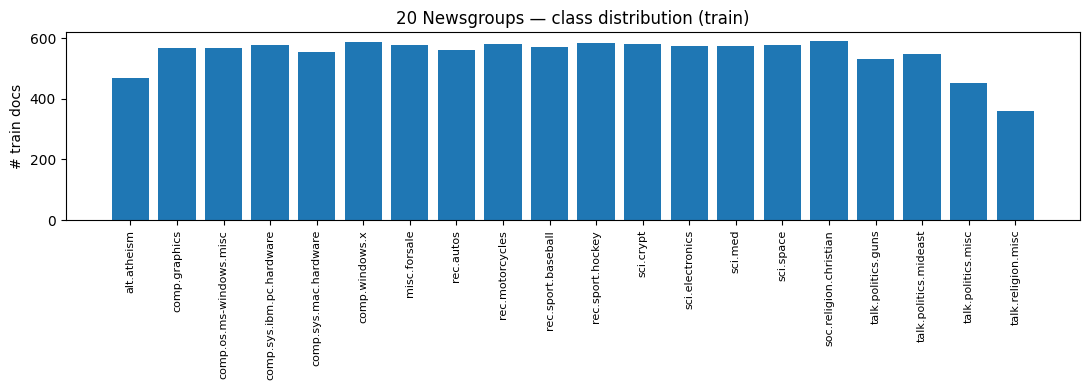

In [6]:
# Class distribution in the train set
counts = Counter(train_labels)
xs = list(range(num_labels))
ys = [counts[i] for i in xs]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(xs, ys)
ax.set_xticks(xs)
ax.set_xticklabels(label_names, rotation=90, fontsize=8)
ax.set_ylabel("# train docs")
ax.set_title("20 Newsgroups — class distribution (train)")
plt.tight_layout(); plt.show()


## 6. Metrics function

Used by the Phase 2 Trainer.

In [7]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_classification_metrics(eval_pred):
    preds, labels = eval_pred
    if preds.ndim == 2:
        preds = preds.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(labels, preds, average="macro",    zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {
        "accuracy":           acc,
        "macro_precision":    p_m,
        "macro_recall":       r_m,
        "macro_f1":           f1_m,
        "weighted_precision": p_w,
        "weighted_recall":    r_w,
        "weighted_f1":        f1_w,
    }


## 7. Phase 1 — MLM (Masked Language Modeling)

`report_to=["wandb"]` in `TrainingArguments` makes the HF Trainer log training/eval loss, learning rate, and system metrics (GPU memory, utilization) to W&B automatically. The Trainer creates and finishes the W&B run for us; we just give it a `run_name`.

> 3 MLM epochs takes ≈ 30–60 minutes on a single consumer GPU. For a smoke test, lower `num_train_epochs` to 1.

In [8]:
from transformers import (
    AutoTokenizer, AutoModelForMaskedLM,
    DataCollatorForLanguageModeling, Trainer, TrainingArguments, set_seed,
)
from datasets import Dataset

set_seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
mlm_model = AutoModelForMaskedLM.from_pretrained(BASE_MODEL)

def tok_mlm(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH,
                     padding=False, return_special_tokens_mask=True)

mlm_train_ds = (Dataset.from_dict({"text": train_texts})
                .map(tok_mlm, batched=True, remove_columns=["text"], desc="Tokenizing train"))
mlm_eval_ds  = (Dataset.from_dict({"text": test_texts})
                .map(tok_mlm, batched=True, remove_columns=["text"], desc="Tokenizing eval"))

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=MLM["mlm_probability"],
)
print(f"Tokenized {len(mlm_train_ds):,} train and {len(mlm_eval_ds):,} eval examples.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Tokenizing train:   0%|          | 0/10990 [00:00<?, ? examples/s]

Tokenizing eval:   0%|          | 0/7299 [00:00<?, ? examples/s]

Tokenized 10,990 train and 7,299 eval examples.


In [9]:
mlm_args = TrainingArguments(
    output_dir                  = str(MLM_CKPT_DIR),
    num_train_epochs            = MLM["num_train_epochs"],
    per_device_train_batch_size = MLM["per_device_train_batch_size"],
    per_device_eval_batch_size  = MLM["per_device_eval_batch_size"],
    learning_rate               = MLM["learning_rate"],
    weight_decay                = MLM["weight_decay"],
    warmup_ratio                = MLM["warmup_ratio"],
    logging_steps               = MLM["logging_steps"],
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 1,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = ["wandb"],
    run_name                    = "task3-phase1-mlm",
    dataloader_num_workers      = 2,
)

mlm_trainer = Trainer(
    model            = mlm_model,
    args             = mlm_args,
    train_dataset    = mlm_train_ds,
    eval_dataset     = mlm_eval_ds,
    data_collator    = collator,
    tokenizer        = tokenizer,   # <- if you're on transformers v5, use `processing_class=tokenizer`
)
mlm_trainer.train()


/tmp/ipykernel_8902/1240533465.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  mlm_trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,2.416000,2.265855
2,2.225600,2.226460
3,2.094200,2.165689


TrainOutput(global_step=2061, training_loss=2.330377632411344, metrics={'train_runtime': 413.3664, 'train_samples_per_second': 79.76, 'train_steps_per_second': 4.986, 'total_flos': 2169465669504000.0, 'train_loss': 2.330377632411344, 'epoch': 3.0})

In [10]:
# Final MLM eval + perplexity
mlm_metrics = mlm_trainer.evaluate()
eval_loss   = mlm_metrics["eval_loss"]
perplexity  = float(np.exp(eval_loss))
print(f"Eval loss : {eval_loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")

# Save final checkpoint — Phase 2 loads from this directory.
mlm_trainer.save_model(str(MLM_CKPT_DIR))
tokenizer.save_pretrained(str(MLM_CKPT_DIR))
print("Saved MLM checkpoint to:", MLM_CKPT_DIR)


Eval loss : 2.1833
Perplexity: 8.88
Saved MLM checkpoint to: /content/outputs/task3_mlm


### Plot the MLM training curve (local backup)

The same curve is in your W&B dashboard, but it's handy to have it inline too.

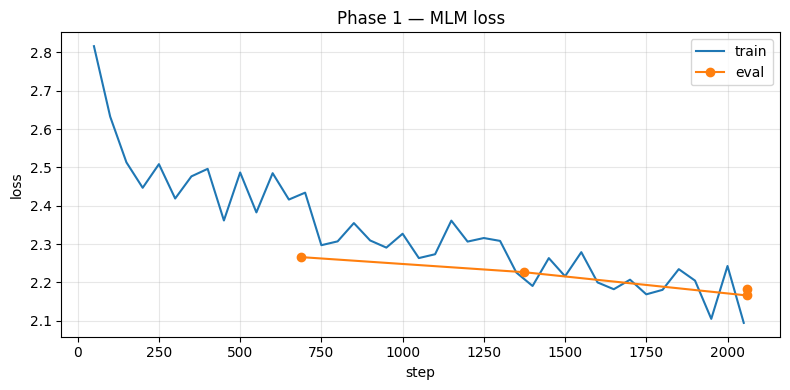

In [11]:
def plot_history(log_history, train_key="loss", eval_key="eval_loss", title=""):
    train_steps, train_vals = [], []
    eval_steps,  eval_vals  = [], []
    for rec in log_history:
        if train_key in rec and "step" in rec:
            train_steps.append(rec["step"]); train_vals.append(rec[train_key])
        if eval_key in rec and "step" in rec:
            eval_steps.append(rec["step"]);  eval_vals.append(rec[eval_key])
    fig, ax = plt.subplots(figsize=(8, 4))
    if train_vals: ax.plot(train_steps, train_vals, label="train")
    if eval_vals:  ax.plot(eval_steps,  eval_vals,  label="eval", marker="o")
    ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

plot_history(mlm_trainer.state.log_history, title="Phase 1 — MLM loss")


### Sanity check — MLM fills in masked words

In [12]:
from transformers import pipeline

fill = pipeline("fill-mask", model=str(MLM_CKPT_DIR), tokenizer=tokenizer,
                device=0 if torch.cuda.is_available() else -1)

for prompt in [
    "The new graphics card has impressive [MASK] performance.",
    "After the launch the [MASK] reached orbit successfully.",
    "I have been debugging a strange [MASK] in my Linux kernel.",
]:
    print(prompt)
    for p in fill(prompt, top_k=3):
        print(f"   -> {p['token_str']:<15} ({p['score']:.3f})")
    print()


Device set to use cuda:0


The new graphics card has impressive [MASK] performance.
   -> display         (0.264)
   -> graphics        (0.231)
   -> system          (0.027)

After the launch the [MASK] reached orbit successfully.
   -> satellite       (0.401)
   -> spacecraft      (0.098)
   -> rocket          (0.090)

I have been debugging a strange [MASK] in my Linux kernel.
   -> bug             (0.125)
   -> feature         (0.114)
   -> problem         (0.056)



## 8. Phase 2 — Classification fine-tuning

A second W&B run, also handled by the Trainer (`run_name="task3-phase2-clf"`).

In [13]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding

set_seed(SEED)

clf_tokenizer = AutoTokenizer.from_pretrained(str(MLM_CKPT_DIR))
clf_model = AutoModelForSequenceClassification.from_pretrained(
    str(MLM_CKPT_DIR),
    num_labels = num_labels,
    id2label   = {i: n for i, n in enumerate(label_names)},
    label2id   = {n: i for i, n in enumerate(label_names)},
)

def tok_clf(batch):
    return clf_tokenizer(batch["text"], truncation=True,
                         max_length=MAX_LENGTH, padding=False)

clf_train_ds = (Dataset.from_dict({"text": train_texts, "labels": train_labels})
                .map(tok_clf, batched=True, remove_columns=["text"], desc="Tokenizing train (clf)"))
clf_test_ds  = (Dataset.from_dict({"text": test_texts,  "labels": test_labels})
                .map(tok_clf, batched=True, remove_columns=["text"], desc="Tokenizing test (clf)"))

clf_collator = DataCollatorWithPadding(tokenizer=clf_tokenizer)
print("Ready to fine-tune classifier from:", MLM_CKPT_DIR)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/outputs/task3_mlm and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing train (clf):   0%|          | 0/10990 [00:00<?, ? examples/s]

Tokenizing test (clf):   0%|          | 0/7299 [00:00<?, ? examples/s]

Ready to fine-tune classifier from: /content/outputs/task3_mlm


In [14]:
clf_args = TrainingArguments(
    output_dir                  = str(CLF_CKPT_DIR),
    num_train_epochs            = CLF["num_train_epochs"],
    per_device_train_batch_size = CLF["per_device_train_batch_size"],
    per_device_eval_batch_size  = CLF["per_device_eval_batch_size"],
    learning_rate               = CLF["learning_rate"],
    weight_decay                = CLF["weight_decay"],
    warmup_ratio                = CLF["warmup_ratio"],
    logging_steps               = CLF["logging_steps"],
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = CLF["metric_for_best_model"],
    greater_is_better           = True,
    save_total_limit            = 1,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = ["wandb"],
    run_name                    = "task3-phase2-clf",
    dataloader_num_workers      = 2,
)

clf_trainer = Trainer(
    model            = clf_model,
    args             = clf_args,
    train_dataset    = clf_train_ds,
    eval_dataset     = clf_test_ds,
    data_collator    = clf_collator,
    tokenizer        = clf_tokenizer,   # <- if you're on transformers v5, use `processing_class=clf_tokenizer`
    compute_metrics  = compute_classification_metrics,
)
clf_trainer.train()


/tmp/ipykernel_8902/3186309458.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  clf_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.021200,1.022164,0.701055,0.682113,0.684162,0.676860,0.700157,0.701055,0.694282
2,0.744600,0.944136,0.723113,0.704941,0.707162,0.701321,0.718240,0.723113,0.716743
3,0.460100,0.949415,0.729278,0.713618,0.713979,0.711134,0.726404,0.729278,0.725520


TrainOutput(global_step=2061, training_loss=0.943015640884392, metrics={'train_runtime': 381.9973, 'train_samples_per_second': 86.31, 'train_steps_per_second': 5.395, 'total_flos': 2169043366533120.0, 'train_loss': 0.943015640884392, 'epoch': 3.0})

## 9. Evaluation

In [15]:
metrics = clf_trainer.evaluate()
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k:30s} {v:.4f}")

clf_trainer.save_model(str(CLF_CKPT_DIR))
clf_tokenizer.save_pretrained(str(CLF_CKPT_DIR))
final = {k: float(v) for k, v in metrics.items() if isinstance(v, (int, float))}
(CLF_CKPT_DIR / "final_metrics.json").write_text(json.dumps(final, indent=2))
print("\nSaved to:", CLF_CKPT_DIR)


eval_loss                      0.9494
eval_accuracy                  0.7293
eval_macro_precision           0.7136
eval_macro_recall              0.7140
eval_macro_f1                  0.7111
eval_weighted_precision        0.7264
eval_weighted_recall           0.7293
eval_weighted_f1               0.7255
eval_runtime                   12.8235
eval_samples_per_second        569.1880
eval_steps_per_second          17.8580
epoch                          3.0000

Saved to: /content/outputs/task3_clf_after_mlm


### Classification training curves (local backup)

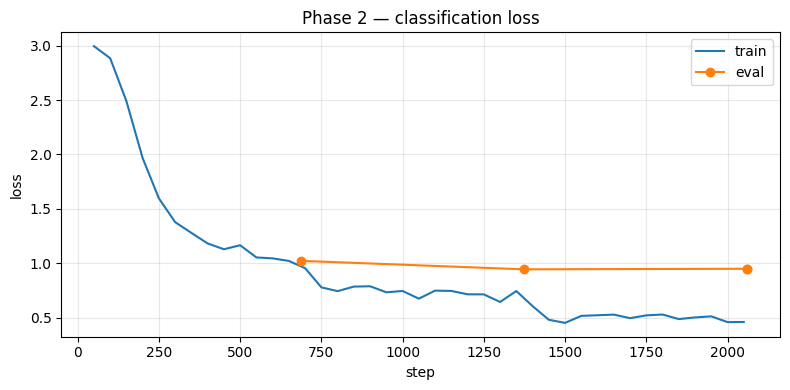

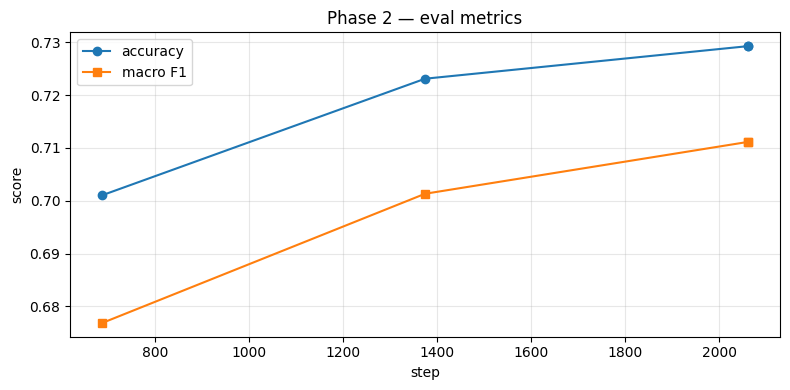

In [16]:
plot_history(clf_trainer.state.log_history,
             train_key="loss", eval_key="eval_loss",
             title="Phase 2 — classification loss")

acc_steps, acc_vals, f1_steps, f1_vals = [], [], [], []
for rec in clf_trainer.state.log_history:
    if "eval_accuracy" in rec:
        acc_steps.append(rec["step"]); acc_vals.append(rec["eval_accuracy"])
    if "eval_macro_f1" in rec:
        f1_steps.append(rec["step"]);  f1_vals.append(rec["eval_macro_f1"])

fig, ax = plt.subplots(figsize=(8, 4))
if acc_vals: ax.plot(acc_steps, acc_vals, marker="o", label="accuracy")
if f1_vals:  ax.plot(f1_steps,  f1_vals,  marker="s", label="macro F1")
ax.set_xlabel("step"); ax.set_ylabel("score"); ax.set_title("Phase 2 — eval metrics")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()


### Confusion matrix

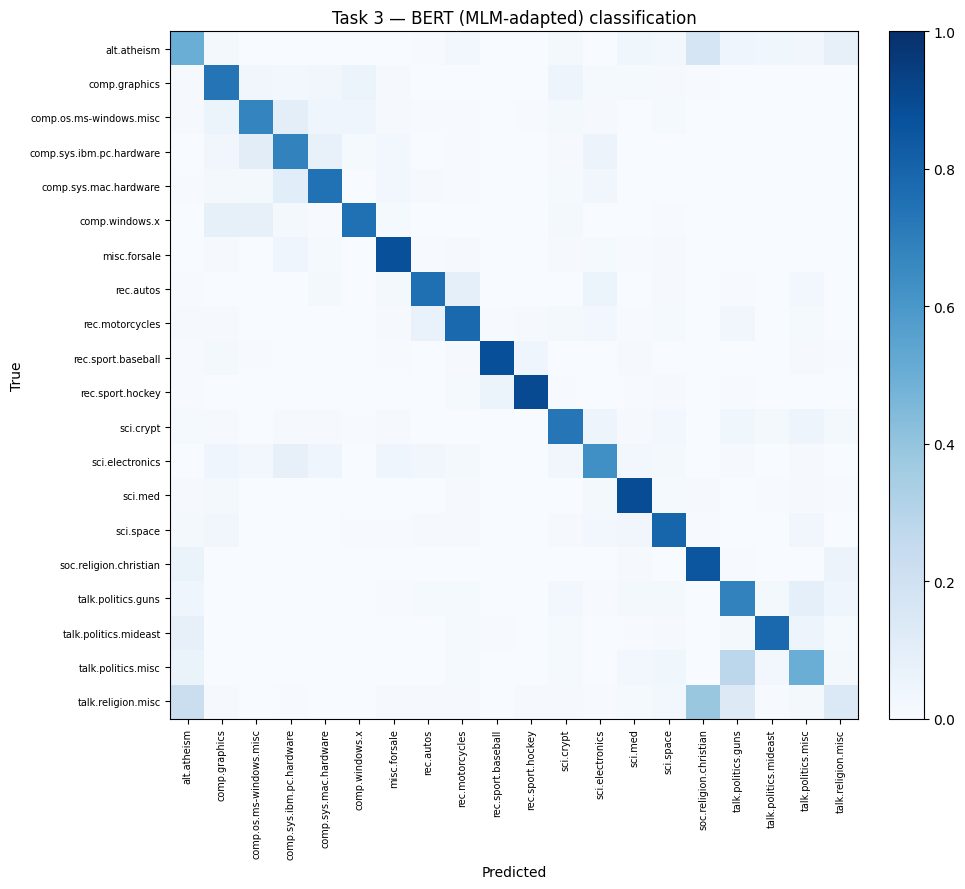

Saved: /content/outputs/figures/task3/task3_confusion_matrix.png


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

preds_output = clf_trainer.predict(clf_test_ds)
y_pred = preds_output.predictions.argmax(axis=-1)
y_true = np.array(preds_output.label_ids)

cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(num_labels)); ax.set_yticks(range(num_labels))
ax.set_xticklabels(label_names, rotation=90, fontsize=7)
ax.set_yticklabels(label_names, fontsize=7)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Task 3 — BERT (MLM-adapted) classification")
plt.tight_layout()

cm_path = FIG_DIR / "task3_confusion_matrix.png"
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", cm_path)


In [18]:
print(classification_report(y_true, y_pred, target_names=label_names, digits=3, zero_division=0))


                          precision    recall  f1-score   support

             alt.atheism      0.463     0.503     0.482       310
           comp.graphics      0.676     0.734     0.704       384
 comp.os.ms-windows.misc      0.697     0.673     0.685       379
comp.sys.ibm.pc.hardware      0.637     0.680     0.657       384
   comp.sys.mac.hardware      0.753     0.749     0.751       371
          comp.windows.x      0.854     0.751     0.799       390
            misc.forsale      0.822     0.876     0.848       380
               rec.autos      0.819     0.755     0.785       371
         rec.motorcycles      0.767     0.779     0.773       384
      rec.sport.baseball      0.923     0.882     0.902       382
        rec.sport.hockey      0.916     0.897     0.906       389
               sci.crypt      0.741     0.729     0.735       380
         sci.electronics      0.673     0.629     0.650       383
                 sci.med      0.813     0.890     0.850       382
         

## 10. (Optional) W&B summary run

The Trainer's W&B runs for Phase 1 and Phase 2 have already been finished. To log the final eval metrics, the confusion matrix, and the MLM perplexity in one place — convenient for the report — we open a third run dedicated to evaluation artifacts.

W&B's `wandb.plot.confusion_matrix` produces an interactive plot in the dashboard, much nicer than the static PNG.

In [19]:
# This run will appear in W&B alongside phase1-mlm and phase2-clf
with wandb.init(
    project=WANDB_PROJECT,
    name="task3-results",
    job_type="evaluation",
    config={
        "base_model":    BASE_MODEL,
        "max_length":    MAX_LENGTH,
        "mlm_epochs":    MLM["num_train_epochs"],
        "clf_epochs":    CLF["num_train_epochs"],
        "mlm_lr":        MLM["learning_rate"],
        "clf_lr":        CLF["learning_rate"],
    },
    reinit=True,
) as run:
    run.log({
        "final/accuracy":       final["eval_accuracy"],
        "final/macro_f1":       final["eval_macro_f1"],
        "final/weighted_f1":    final.get("eval_weighted_f1"),
        "final/mlm_perplexity": perplexity,
        # interactive confusion matrix
        "confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=y_true,
            preds=y_pred,
            class_names=label_names,
        ),
    })
    # Also upload the static PNG as an artifact
    run.log({"confusion_matrix_image": wandb.Image(str(cm_path))})

print("W&B summary logged. Check the run in your project dashboard.")


eval/accuracy,▁▆██
eval/loss,██▇█▁▁▁▁
eval/macro_f1,▁▆██
eval/macro_precision,▁▆██
eval/macro_recall,▁▆██
eval/runtime,▆▆█▆▁▁▁▁
eval/samples_per_second,▃▂▁▂████
eval/steps_per_second,▃▂▁▂████
eval/weighted_f1,▁▆██
eval/weighted_precision,▁▆██
+17,...


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


final/accuracy,▁
final/macro_f1,▁
final/mlm_perplexity,▁
final/weighted_f1,▁
final/accuracy,0.72928
final/macro_f1,0.71113
final/mlm_perplexity,8.87556
final/weighted_f1,0.72552


W&B summary logged. Check the run in your project dashboard.


## 11. Comparison with Task 2 (vanilla BERT)

Loads Task 2 metrics from `outputs/task2_clf/final_metrics.json` if present.

In [21]:
import pandas as pd

task3_metrics = final
task2_path = OUT_DIR / "task2_clf" / "final_metrics.json"
if task2_path.exists():
    task2_metrics = json.loads(task2_path.read_text())
else:
    print(f"(no Task 2 metrics at {task2_path} — fill in manually)")
    task2_metrics = {"eval_accuracy": "0.6986", "eval_macro_f1": "0.6811"}

df = pd.DataFrame({
    "Task 2 (vanilla BERT)": [task2_metrics.get("eval_accuracy"), task2_metrics.get("eval_macro_f1")],
    "Task 3 (MLM + BERT)":   [task3_metrics.get("eval_accuracy"), task3_metrics.get("eval_macro_f1")],
}, index=["accuracy", "macro F1"])
df


(no Task 2 metrics at /content/outputs/task2_clf/final_metrics.json — fill in manually)


,Task 2 (vanilla BERT),Task 3 (MLM + BERT)
accuracy,0.6986,0.729278
macro F1,0.6811,0.711134


## 12. Discussion (to expand in the report)

- **Did the MLM phase help?** Expect a small but consistent gain (≈1–3 acc points). 20-news is small and stylistically distinct (USENET-era posts; lots of jargon), so DAPT typically moves the needle.
- **Where does the gain come from?** Inspect the confusion matrix — MLM usually helps most on fine-grained groups that share vocabulary (`comp.sys.ibm.pc.hardware` vs `comp.sys.mac.hardware`, the three `rec.sport.*`, the three `talk.politics.*`).
- **Cost.** Phase 1 roughly doubles training time vs Task 2 for a modest accuracy gain.
- **Follow-ups** to mention: longer MLM (watch perplexity for overfitting), whole-word masking, higher `mlm_probability` (0.2), multi-task with the MLM head kept on.

## 13. Artefacts for the report

- `outputs/task3_mlm/` — MLM-adapted encoder + tokenizer
- `outputs/task3_clf_after_mlm/` — classifier checkpoint + `final_metrics.json`
- `outputs/figures/task3/task3_confusion_matrix.png`
- **W&B runs:** `task3-phase1-mlm`, `task3-phase2-clf`, `task3-results` — paste their URLs into your report.